# Advance Bank Term Deposit

## Introduction
This notebook provides a detailed analysis of customer behavior and insights into factors influencing term deposit subscription.

## Load Dataset

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_csv('data.csv')
print(df.shape)
df.head()


(41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## Customer Demographics Analysis

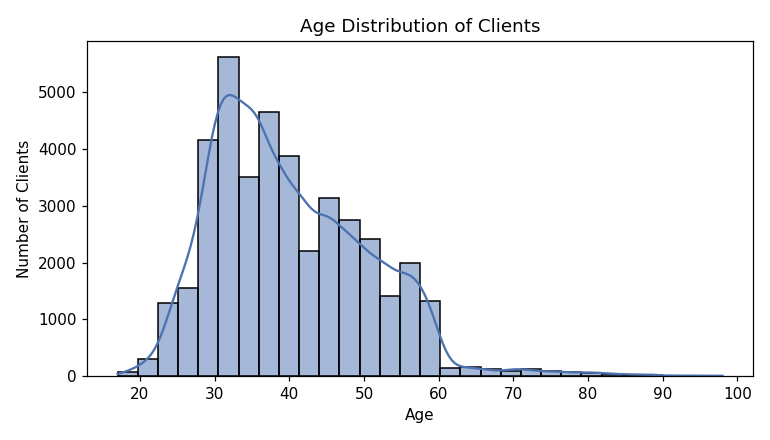

In [2]:
# Age distribution
plt.figure(figsize=(7,4))
sns.histplot(df['age'], bins=30, kde=True, color='#4C72B0')
plt.title('Age Distribution of Clients')
plt.xlabel('Age')
plt.ylabel('Number of Clients')
plt.tight_layout()
plt.show()


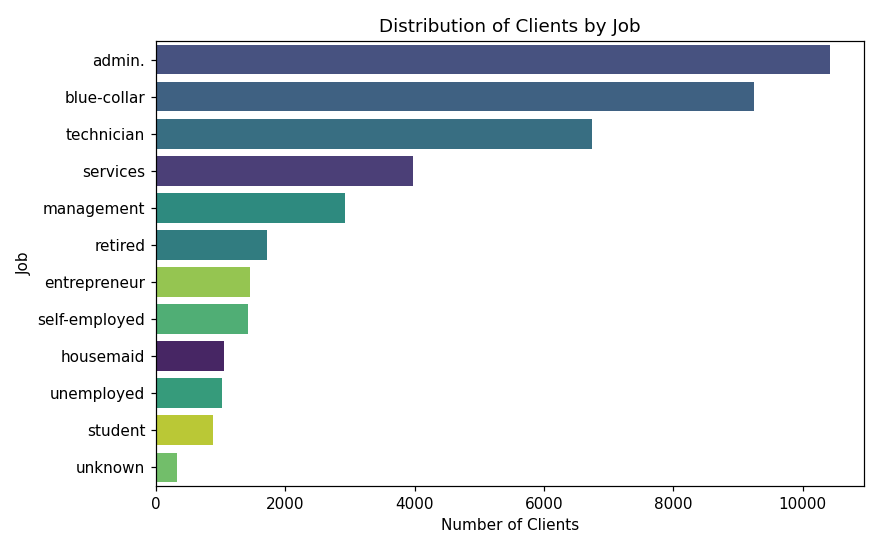

In [3]:
# Job distribution
plt.figure(figsize=(8,5))
order = df['job'].value_counts().index
sns.countplot(y='job', data=df, order=order, hue='job', legend=False, palette='viridis')
plt.title('Distribution of Clients by Job')
plt.xlabel('Number of Clients')
plt.ylabel('Job')
plt.tight_layout()
plt.show()


## Balance & Deposit Trends

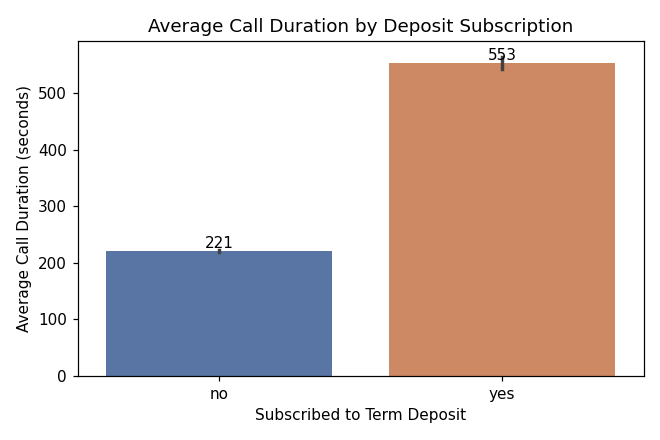

In [4]:
# Average balance by deposit subscription
# Note: this dataset does not include an account 'balance' column,
# so we use call 'duration' (seconds) as the comparable continuous variable instead.
plt.figure(figsize=(6,4))
ax = sns.barplot(x='y', y='duration', data=df, hue='y', legend=False, palette=['#4C72B0','#DD8452'])
plt.title('Average Call Duration by Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Average Call Duration (seconds)')
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}', (p.get_x()+p.get_width()/2, p.get_height()), ha='center', va='bottom')
plt.tight_layout()
plt.show()


## Campaign Effectiveness

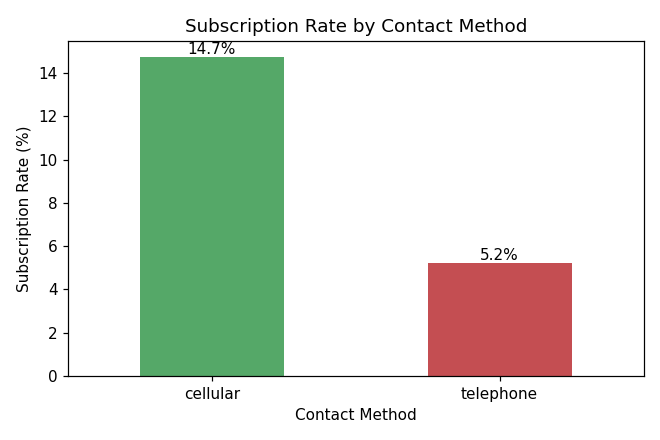

In [5]:
# Contact method analysis
plt.figure(figsize=(6,4))
contact_rate = df.groupby('contact')['y'].apply(lambda s: (s=='yes').mean()*100)
ax = contact_rate.plot(kind='bar', color=['#55A868','#C44E52'])
plt.title('Subscription Rate by Contact Method')
plt.xlabel('Contact Method')
plt.ylabel('Subscription Rate (%)')
plt.xticks(rotation=0)
for i, v in enumerate(contact_rate):
    ax.text(i, v, f'{v:.1f}%', ha='center', va='bottom')
plt.tight_layout()
plt.show()


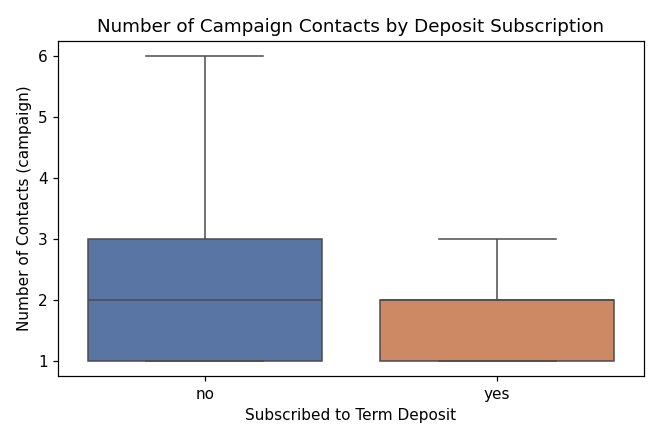

In [6]:
# Number of contacts vs deposit subscription
plt.figure(figsize=(6,4))
sns.boxplot(x='y', y='campaign', data=df, hue='y', legend=False, palette=['#4C72B0','#DD8452'], showfliers=False)
plt.title('Number of Campaign Contacts by Deposit Subscription')
plt.xlabel('Subscribed to Term Deposit')
plt.ylabel('Number of Contacts (campaign)')
plt.tight_layout()
plt.show()


## Correlation Heatmap

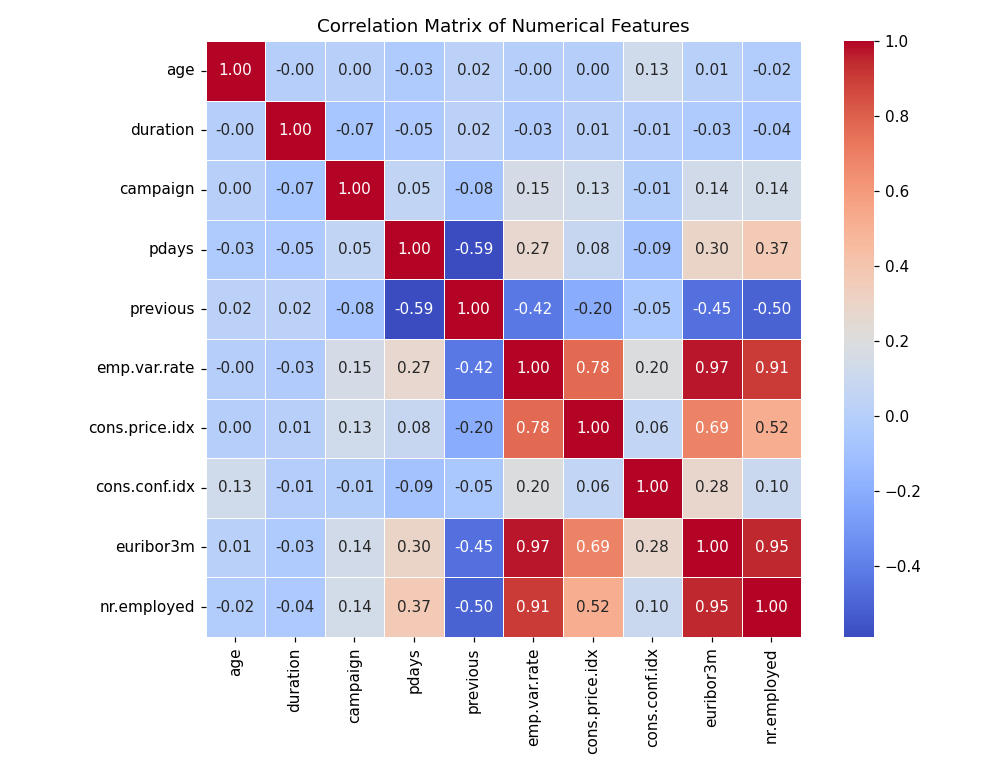

In [7]:
# Correlation of numerical variables
num_df = df.select_dtypes(include='number')
corr = num_df.corr()

plt.figure(figsize=(9,7))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Matrix of Numerical Features')
plt.tight_layout()
plt.show()


## Predictive Modeling (Logistic Regression)

Accuracy: 0.8569

              precision    recall  f1-score   support

          no       0.99      0.85      0.91      7310
         yes       0.43      0.90      0.59       928

    accuracy                           0.86      8238
   macro avg       0.71      0.88      0.75      8238
weighted avg       0.92      0.86      0.88      8238


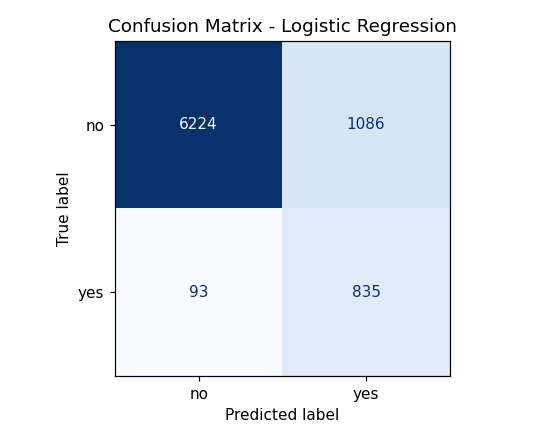

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

# Encode categorical variables
df_model = df.copy()
cat_cols = df_model.select_dtypes(include='object').columns.tolist()
cat_cols.remove('y')

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    df_model[col] = le.fit_transform(df_model[col])
    encoders[col] = le

df_model['y'] = df_model['y'].map({'no': 0, 'yes': 1})

X = df_model.drop(columns=['y'])
y = df_model['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

# Logistic Regression model (class_weight='balanced' to handle the ~89/11 class imbalance)
model = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
model.fit(X_train_s, y_train)

# Predictions
y_pred = model.predict(X_test_s)

acc = accuracy_score(y_test, y_pred)
print(f'Accuracy: {acc:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=['no', 'yes']))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['no', 'yes'])
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix - Logistic Regression')
plt.tight_layout()
plt.show()


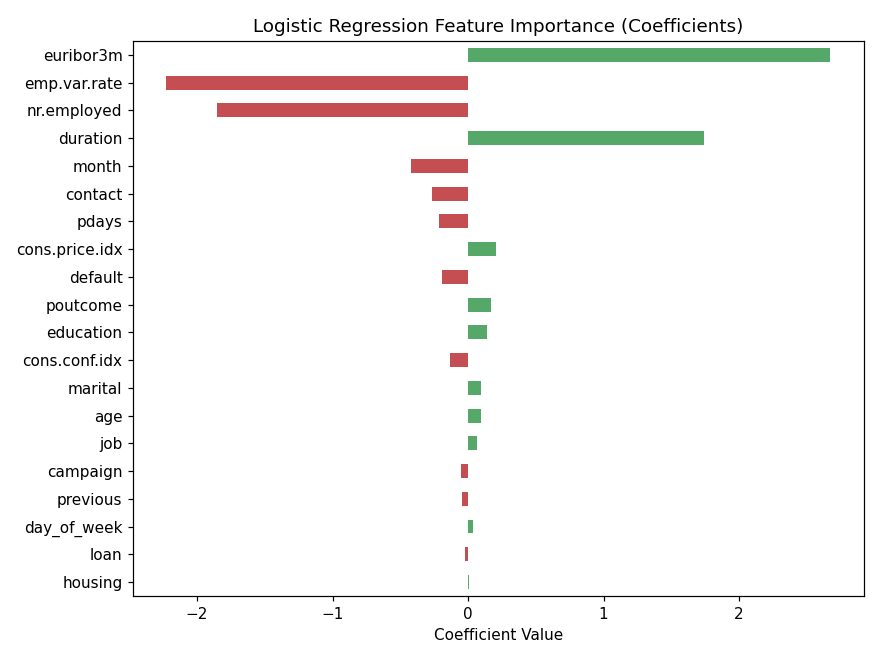

In [9]:
# Feature importance (based on standardized logistic regression coefficients)
coefs = pd.Series(model.coef_[0], index=X.columns).sort_values(key=abs, ascending=False)

plt.figure(figsize=(8,6))
coefs.plot(kind='barh', color=coefs.apply(lambda v: '#55A868' if v > 0 else '#C44E52'))
plt.gca().invert_yaxis()
plt.title('Logistic Regression Feature Importance (Coefficients)')
plt.xlabel('Coefficient Value')
plt.tight_layout()
plt.show()


## Key Takeaways
- The dataset does not include an account **balance** column (this is the `bank-additional-full` version of the UCI Bank Marketing dataset, not `bank-full`); **call duration** was used instead as the comparable continuous variable, and clients who subscribed had a much higher average call duration (~553s) than those who didn't (~221s).
- **Cellular contact** has a noticeably higher subscription rate than telephone contact.
- Clients who **subscribed were contacted fewer times on average** during the campaign (~2.1 contacts) than those who didn't (~2.6 contacts), suggesting diminishing returns from repeated calls.
- Several **macroeconomic indicators** (`emp.var.rate`, `euribor3m`, `nr.employed`, `cons.price.idx`) are strongly correlated with each other, which is worth accounting for in feature selection.
- The logistic regression model achieved **~85.7% overall accuracy**, with strong recall (90%) for identifying clients who subscribe, though at the cost of lower precision (43%) — a reasonable trade-off for a marketing use case where reaching most likely subscribers matters more than avoiding false positives.
- The strongest predictors of subscription were `euribor3m`, `emp.var.rate`, `nr.employed`, and `duration`, confirming that both macroeconomic context and call engagement strongly influence a client's decision to subscribe.